In [32]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import os

In [33]:
os.environ["PATH"] = "/vast/palmer/apps/avx2/software/texlive/20220321-GCC-12.2.0/bin/x86_64-linux:" + os.environ["PATH"]
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{lmodern}",
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 6,
    "figure.figsize": [8, 5.6],
    "svg.fonttype": "none",
    "image.cmap": "viridis",
})

In [34]:
ROOT_DIR = Path("/home/rg2248/project/friction/data/height-distributions/thomson")


def load_data(data_dir):
    files = sorted(
        data_dir.glob("r-*.npz"),
        key=lambda path: float(path.stem.removeprefix("r-")),
    )
    return {
        float(path.stem.removeprefix("r-")): dict(np.load(path))
        for path in files
    }


def load_all_data(root_dir):
    data = {}
    for nv_dir in sorted(root_dir.glob("n-*")):
        nv = int(nv_dir.name.split("-", 1)[1])
        data[nv] = load_data(nv_dir)
    return data


data = load_all_data(ROOT_DIR)
nv_values = np.array(sorted(data.keys()))

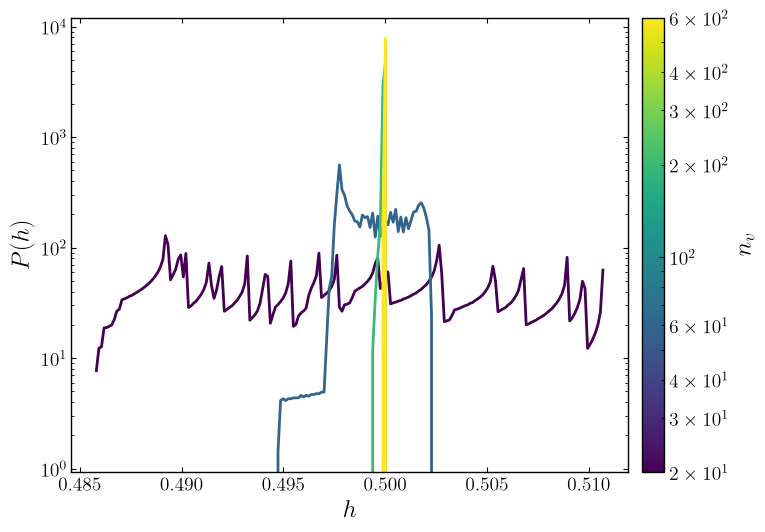

In [36]:
from matplotlib.colors import LogNorm

asperity_radius = 0.1

all_heights = np.concatenate([data[nv][asperity_radius]["heights"] for nv in nv_values])
bins = np.linspace(all_heights.min(), all_heights.max(), 200)
centers = 0.5 * (bins[:-1] + bins[1:])
norm = LogNorm(nv_values.min(), nv_values.max())
cmap = plt.get_cmap("viridis")


def density(values):
    counts, _ = np.histogram(values, bins=bins)
    probability = counts / (len(values) * np.diff(bins))
    return probability, counts


fig, ax = plt.subplots()

for nv in nv_values:
    record = data[nv][asperity_radius]
    heights = record["heights"]
    probability, _ = density(heights)
    ax.plot(
        centers,
        probability,
        color=cmap(norm(nv)),
        label=rf"$n_v={nv}$",
    )

colorbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax,
    pad=0.02,
)
colorbar.set_label(r"$n_v$")
ax.set_xlabel(r"$h$")
ax.set_ylabel(r"$P(h)$")
ax.set_yscale("log")
# ax.legend(frameon=False, fontsize=12, title=rf"$r_a={asperity_radius}$")
plt.tight_layout()
plt.show()